# Notebook 4 — Is the fit any good?

*SWC ENC 2026 · behaviour module*

On synthetic mice we can check a fit against ground truth. On **real** mice we
can't — so we need a way to judge a model by how well it **predicts behavior we
didn't fit it to**. That's this notebook: the ROC curve, the AUC, and
cross-validation. It's the machinery behind Figure 2A.

**In this notebook you will:**
1. See why plain accuracy is misleading when licking is rare.
2. Build the **ROC curve** and summarize it with the **AUC**.
3. Use **cross-validation** to get an honest, non-overfit score.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import rankdata
import swcbehav as sb

def get_Xy(sess):
    # Observable design matrix and per-image bout outcome.
    X, cols = sb.build_design_matrix(sess.table)
    y = sess.table["bout_start"].to_numpy().astype(float)
    return X, y, cols

# fit_static / predict_prob were built in Notebook 3; import them from the backend.
sess = sb.make_mouse("visual", seed=0)
X, y, cols = get_Xy(sess)
w = sb.fit_static(X, y)
scores = sb.predict_prob(w, X)      # model probability of a bout on each image

## 1. Why not just use accuracy?

Licking bouts are rare — most images have no bout. So a lazy model that predicts
"never lick" is *right* most of the time and yet tells us nothing. Accuracy is
dominated by the majority class.

In [2]:
base_rate = y.mean()
naive_accuracy = 1 - base_rate     # "never lick" is right on every non-bout image
print(f"bouts occur on {base_rate:.1%} of images")
print(f"a 'never lick' model has accuracy {naive_accuracy:.1%} -- and zero value")

bouts occur on 17.9% of images
a 'never lick' model has accuracy 82.1% -- and zero value


## 2. The ROC curve

The model outputs a *probability* per image, not a yes/no. Turn it into a
decision by thresholding: predict "bout" when the score exceeds some cutoff. Each
cutoff gives a **true-positive rate** (bouts correctly flagged) and a
**false-positive rate** (quiet images wrongly flagged). Sweeping the cutoff
traces the **ROC curve**. A useless model hugs the diagonal; a good one bows
toward the top-left.

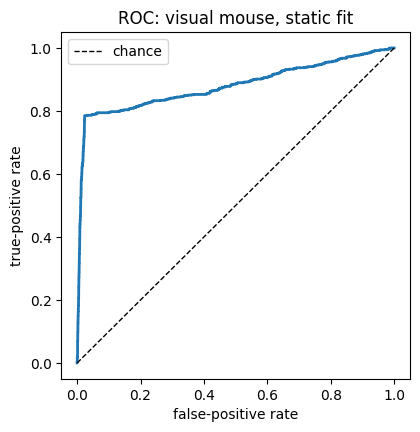

In [3]:
fpr, tpr = sb.roc_curve(scores, y)
plt.figure(figsize=(4.5, 4.5))
plt.plot(fpr, tpr, lw=2)
plt.plot([0, 1], [0, 1], "k--", lw=1, label="chance")
plt.xlabel("false-positive rate"); plt.ylabel("true-positive rate")
plt.title("ROC: visual mouse, static fit"); plt.legend()
plt.show()

## 3. AUC — one number for the whole curve

The **area under the ROC curve** summarizes it in a single threshold-free number.
It has a clean interpretation: **the probability that the model gives a higher
score to a randomly chosen bout image than to a randomly chosen quiet image.**
0.5 is chance, 1.0 is perfect. That interpretation gives a shortcut to compute it
— no threshold sweep needed — from the **ranks** of the scores:

$$\text{AUC} = \frac{R_{+} - n_{+}(n_{+}+1)/2}{n_{+}\,n_{-}},$$

where $R_{+}$ is the summed rank of the bout images and $n_{+}, n_{-}$ are the
counts of bout / quiet images.

**Exercise 1.** Complete `auc_score`. `rankdata` (imported above) returns ranks
and averages ties correctly — important here, because many images share an
identical design row and hence an identical score.

In [4]:
def auc_score(scores, y):
    y = np.asarray(y).astype(bool)
    n_pos, n_neg = y.sum(), (~y).sum()
    ranks = rankdata(scores)
    return (ranks[y].sum() - n_pos * (n_pos + 1) / 2) / (n_pos * n_neg)

In [5]:
print("your AUC     :", round(auc_score(scores, y), 3))
print("backend AUC  :", round(sb.auc_score(scores, y), 3))

your AUC     : 0.88
backend AUC  : 0.88


## 4. Cross-validation: an honest score

That AUC was measured on the **same data** we fit — it's optimistic. The fair
test is prediction on **held-out** images. We split the session into contiguous
time blocks, fit on all but one, score the one left out, and repeat. (Contiguous
blocks, not random images, so neighboring images don't leak between train and
test.)

**Exercise 2.** Fill in the fit-and-score step inside the cross-validation loop.

In [6]:
def cross_val_auc(X, y, n_folds=5):
    n = len(y)
    folds = np.array_split(np.arange(n), n_folds)
    aucs = []
    for i in range(n_folds):
        test = folds[i]
        train = np.setdiff1d(np.arange(n), test)
        w = sb.fit_static(X[train], y[train])
        aucs.append(auc_score(sb.predict_prob(w, X[test]), y[test]))
    return np.array(aucs)

In [7]:
cv = cross_val_auc(X, y)
print(f"in-sample AUC       : {auc_score(scores, y):.3f}")
print(f"cross-validated AUC : {cv.mean():.3f} +/- {cv.std():.3f}")

in-sample AUC       : 0.880
cross-validated AUC : 0.870 +/- 0.019


The two are close here — the static model has few parameters, so it barely
overfits. Cross-validation matters more once models get flexible (the dynamic
model in Notebook 7 can chase noise if its smoothing is too loose).

## 5. AUC across many mice

Finally, the population view behind Figure 2A. The static model predicts
**static** mice well. On **dynamic** mice — whose strategy drifts — one fixed
weight vector trained on early images predicts late images poorly, so its
held-out AUC sags. That gap is the quantitative case for the dynamic model.

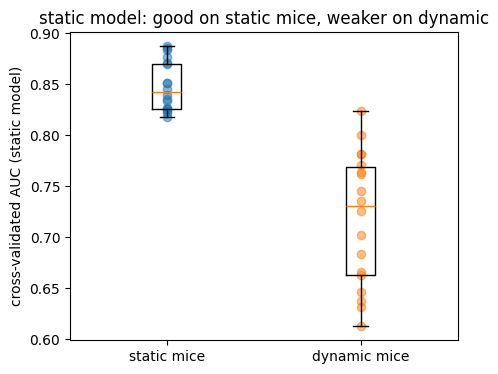

static mice : 0.848
dynamic mice: 0.718


In [8]:
def mouse_cv_auc(archetype, seed):
    X, y, _ = get_Xy(sb.make_mouse(archetype, seed=seed))
    return cross_val_auc(X, y).mean()

static_aucs = [mouse_cv_auc(a, s) for s in range(6) for a in ["visual", "timing", "mixed"]]
dynamic_aucs = [mouse_cv_auc("dynamic", s) for s in range(18)]

plt.figure(figsize=(5, 4))
plt.boxplot([static_aucs, dynamic_aucs])
plt.xticks([1, 2], ["static mice", "dynamic mice"])
plt.scatter(np.ones(len(static_aucs)), static_aucs, alpha=0.5)
plt.scatter(2 * np.ones(len(dynamic_aucs)), dynamic_aucs, alpha=0.5)
plt.ylabel("cross-validated AUC (static model)")
plt.title("static model: good on static mice, weaker on dynamic")
plt.show()
print(f"static mice : {np.mean(static_aucs):.3f}")
print(f"dynamic mice: {np.mean(dynamic_aucs):.3f}")

## Wrap-up

You now have an honest yardstick for a behavioral model: the ROC curve, its AUC,
and a cross-validated estimate that doesn't flatter the fit. You also saw the
static model's held-out performance drop on dynamic mice — foreshadowing.

**Next (Notebook 5):** the AUC says *how well* the model predicts, but not *which
strategies* it's using. For that we turn to model evidence and ablation — and on
our single-strategy mice the answer will be reassuringly obvious.